# Information Loss: When Many Truths Collapse to One Observation

**Building 21 Showcase — McGill University**

Two images. One is a blurry photograph taken at dusk. The other is a thermal satellite image of coastal Antarctica.

Different sensors, different scenes, different scales. But they share the same fundamental problem:

> **The observation is a many-to-one map. You cannot uniquely reconstruct what was there from the observation alone.**

A blurry photograph averages light across time and space. You see the *glow* of a skyline, but not its edges.
A satellite pixel averages temperature across a ~1 km footprint. You see *one number*, but not the mosaic of ice, water, and cloud beneath.

In both cases, many possible "truths" collapse to the same single observation. Picking one of them back out requires assumptions the observation itself doesn't supply.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, laplace, generic_filter
from scipy.signal import convolve2d
import cmocean
import os

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10

---
## 1. Two images, one idea

A blurry photograph and a MODIS thermal image. Different sensors, different scales, different scenes. But both represent observations where fine detail has been **averaged away**.

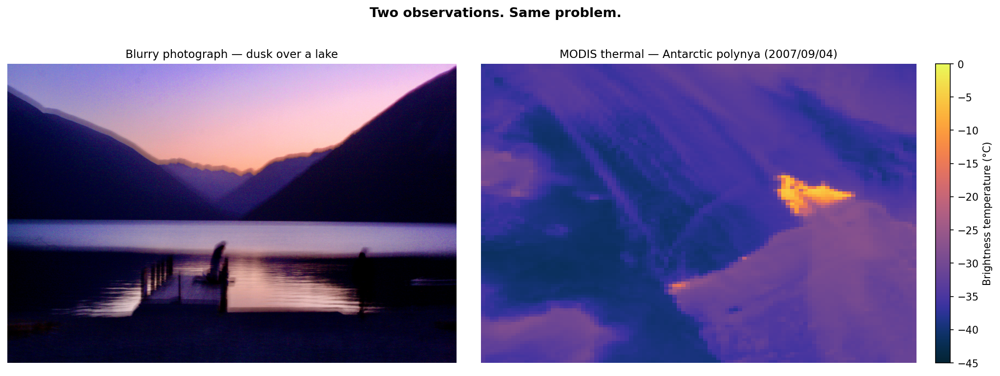

In [2]:
# Load the photograph
photo = np.array(Image.open('photo.jpeg'))

# Load MODIS thermal Band 31 brightness temperature (preprocessed subset)
B31_sub = np.load('data/modis_thermal_B31.npz')['B31_sub']

# --- Side by side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(photo)
ax1.set_title('Blurry photograph — dusk over a lake', fontsize=11)
ax1.axis('off')

im = ax2.imshow(B31_sub, cmap=cmocean.cm.thermal, vmin=-45, vmax=0, aspect='auto')
ax2.set_title('MODIS thermal — Antarctic polynya (2007/09/04)', fontsize=11)
ax2.axis('off')
plt.colorbar(im, ax=ax2, label='Brightness temperature (°C)', fraction=0.046, pad=0.04)

plt.suptitle('Two observations. Same problem.', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 2. What blur hides: the photograph

This photograph was taken in low light with a long exposure. Motion blur and low photon counts
smear the scene. The mountains, the dock, the water — they become *gradients* instead of *edges*.

Where is the skyline exactly? The blur has smoothed together many possible answers into the same image,
so you can't tell them apart from this photograph alone.

We can *map* where fine-scale detail still survives in the image using two simple tools:

**Local variance** — In a small window around each pixel, how much do the values vary?

$$
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \bar{x})^2
$$

where $x_i$ is the brightness of pixel $i$ in the window, $\bar{x}$ is the mean brightness
of the window, and $N$ is the number of pixels in the window.

If nearby pixels all have similar brightness (a smooth, blurry region), variance is low.
If they jump between light and dark (an edge, a texture), variance is high.
High variance = detail survived in the image. Low variance = the blur smoothed it out.

**Laplacian** — The second spatial derivative of the image, measuring how quickly brightness *changes direction*:

$$
\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}
$$

where $I$ is image brightness and $x$, $y$ are the horizontal and vertical spatial directions.

A smooth gradient has a small Laplacian. A sharp edge where brightness jumps abruptly
produces a large response. The Laplacian picks out exactly the structures that blur attenuates first.


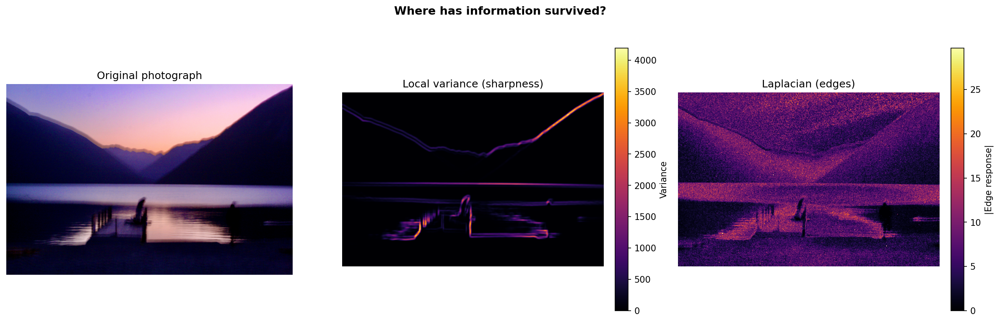

In [3]:
# Sharpness map via local variance — reveals where detail survives vs. is lost
from PIL import Image as PILImage_sharp

# Downsample for faster computation
scale = 4
photo_small = np.array(PILImage_sharp.fromarray(photo).resize(
    (photo.shape[1]//scale, photo.shape[0]//scale), PILImage_sharp.BILINEAR))
photo_gray = np.mean(photo, axis=2).astype(np.float32)
photo_gray_small = np.mean(photo_small, axis=2).astype(np.float32)

def local_var(block):
    return np.var(block)

sharpness = generic_filter(photo_gray_small, local_var, size=7)

# Laplacian edge detection (fast, runs on full res)
lap = np.abs(laplace(photo_gray))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(photo)
axes[0].set_title('Original photograph')
axes[0].axis('off')

im1 = axes[1].imshow(sharpness, cmap='inferno')
axes[1].set_title('Local variance (sharpness)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='Variance')

im2 = axes[2].imshow(lap, cmap='inferno', vmax=np.percentile(lap, 99))
axes[2].set_title('Laplacian (edges)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label='|Edge response|')

plt.suptitle('Where has information survived?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. What a pixel hides: the satellite image

Each MODIS pixel covers ~1 km². The temperature you see is a *single number* — the average
thermal emission from everything inside that footprint: open water, thin ice, thick ice,
meltponds, snow.

Many different mosaics of surface types can produce the **exact same pixel temperature**.
The pixel cannot distinguish between them.


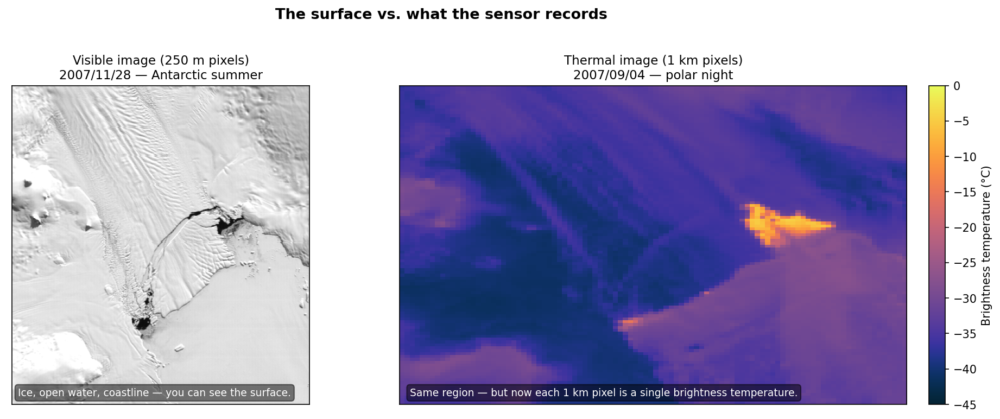

In [4]:
# Aside: what does this place actually look like?
# Preprocessed MODIS visible-band subset (2007/11/28 — same region, Antarctic summer)
B1_sub = np.load('data/modis_visible_B1.npz')['B1_sub']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(B1_sub, cmap='gray', vmin=0, vmax=10000)
ax1.set_title('Visible image (250 m pixels)\n2007/11/28 — Antarctic summer', fontsize=11)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.text(0.02, 0.02, 'Ice, open water, coastline — you can see the surface.',
         transform=ax1.transAxes, fontsize=9, color='white',
         bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.3'),
         va='bottom')

im2 = ax2.imshow(B31_sub, cmap=cmocean.cm.thermal, vmin=-45, vmax=0, aspect='auto')
ax2.set_title('Thermal image (1 km pixels)\n2007/09/04 — polar night', fontsize=11)
ax2.set_xticks([]); ax2.set_yticks([])
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Brightness temperature (°C)')
ax2.text(0.02, 0.02, 'Same region — but now each 1 km pixel is a single brightness temperature.',
         transform=ax2.transAxes, fontsize=9, color='white',
         bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.3'),
         va='bottom')

plt.suptitle('The surface vs. what the sensor records', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


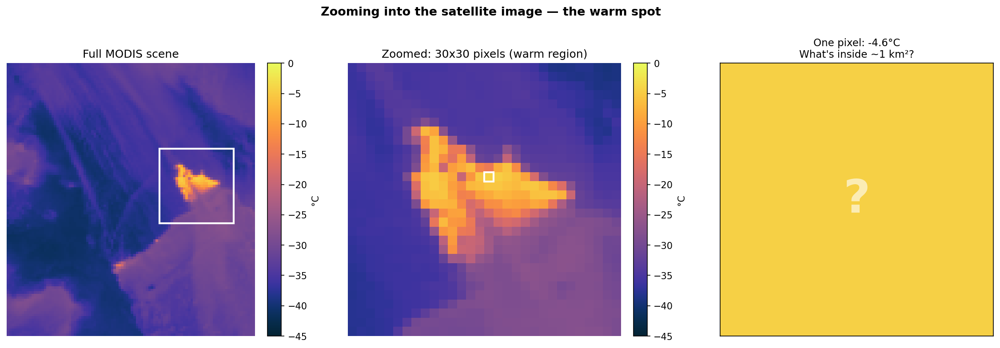

In [5]:
# Zoom into a small patch of the MODIS thermal image to see individual pixels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Full view
im0 = axes[0].imshow(B31_sub, cmap=cmocean.cm.thermal, vmin=-45, vmax=0)
axes[0].set_title('Full MODIS scene')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='°C')

# Find the warmest region (open water / polynya) to zoom into
from scipy.ndimage import uniform_filter
warm_smooth = uniform_filter(np.nan_to_num(B31_sub, nan=-50), size=15)
warm_center = np.unravel_index(np.argmax(warm_smooth), warm_smooth.shape)
rc, cc = warm_center
half = 15
r1, r2 = max(0, rc - half), min(B31_sub.shape[0], rc + half)
c1, c2 = max(0, cc - half), min(B31_sub.shape[1], cc + half)

# Draw zoom box on full view
rect = plt.Rectangle((c1, r1), c2 - c1, r2 - r1, linewidth=2,
                      edgecolor='white', facecolor='none')
axes[0].add_patch(rect)

# Zoomed view — individual pixels visible, centered on warm spot
patch = B31_sub[r1:r2, c1:c2]
im1 = axes[1].imshow(patch, cmap=cmocean.cm.thermal, vmin=-45, vmax=0, interpolation='nearest')
axes[1].set_title(f'Zoomed: {patch.shape[0]}x{patch.shape[1]} pixels (warm region)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='°C')

# Single pixel — the warmest one — what's inside?
pixel_temp = np.nanmax(patch)
pr, pc = np.unravel_index(np.nanargmax(patch), patch.shape)

# Highlight pixel on zoomed view
rect2 = plt.Rectangle((pc - 0.5, pr - 0.5), 1, 1, linewidth=2,
                       edgecolor='white', facecolor='none')
axes[1].add_patch(rect2)

axes[2].imshow([[pixel_temp]], cmap=cmocean.cm.thermal, vmin=-45, vmax=0,
               interpolation='nearest', extent=[0, 1, 0, 1])
axes[2].set_title(f'One pixel: {pixel_temp:.1f}°C\nWhat\'s inside ~1 km²?', fontsize=11)
axes[2].set_xticks([])
axes[2].set_yticks([])
axes[2].text(0.5, 0.5, '?', ha='center', va='center', fontsize=50,
             color='white', fontweight='bold', alpha=0.6)

plt.suptitle('Zooming into the satellite image — the warm spot', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Progressive pixelation: watching detail disappear

What happens when we progressively reduce the resolution of the photograph?
Each step is a non-invertible averaging — like the satellite sensor integrating over larger and larger footprints.
Many different fine-scale scenes map to the same coarse image.

The image becomes the satellite pixel.


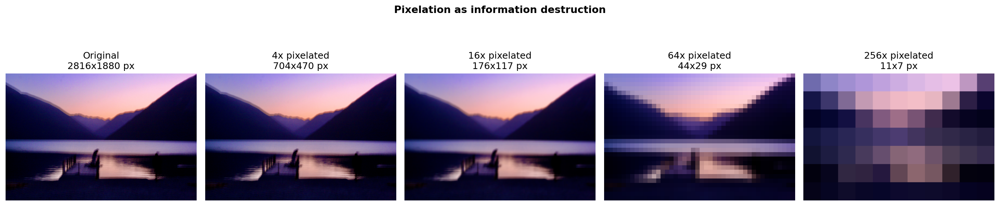

In [6]:
from PIL import Image as PILImage

resolutions = [1, 4, 16, 64, 256]
fig, axes = plt.subplots(1, len(resolutions), figsize=(18, 4))

h, w = photo.shape[:2]
for i, block in enumerate(resolutions):
    if block == 1:
        axes[i].imshow(photo)
        axes[i].set_title(f'Original\n{w}x{h} px')
    else:
        # Block-average by downsampling then upsampling (nearest neighbor for visual)
        small = np.array(PILImage.fromarray(photo).resize((w//block, h//block), PILImage.BILINEAR))
        big = np.array(PILImage.fromarray(small).resize((w, h), PILImage.NEAREST))
        axes[i].imshow(big)
        axes[i].set_title(f'{block}x pixelated\n{w//block}x{h//block} px')
    axes[i].axis('off')

plt.suptitle('Pixelation as information destruction', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 5. Non-unique reconstruction: the skyline problem

Draw a horizontal line through the photograph where the mountains meet the sky (the cyan dashed line below).
Along that line, each pixel records a brightness — dark where mountain blocks the sky, bright where the
sunset glows through the gap. This gives us a 1D **intensity profile** of the skyline.

But the photograph is blurry. The camera averaged light over time (long exposure) and space (out of focus),
so the profile we observe is *smooth* — the sharp transitions between mountain and sky have been smeared out.

Now ask: **what did the sharp skyline actually look like?**

From this observation alone, we can't know. The blur is a smoothing operation — mathematically, a convolution —
and many different sharp profiles map to the same smooth output. A jagged ridge, a smooth dome, a notched cliff
can all blur to the same gentle curve, and the observation treats them as identical.

The bottom panel shows this: the **white line** is the observed (blurry) intensity profile. The colored
lines are different *possible* sharp skylines — each with different edges and details — that would all
produce that same smooth white curve when blurred. Nothing in the observation itself tells us which one
is correct. Choosing between them requires information from somewhere else (a prior, another measurement,
a model of what skylines look like).


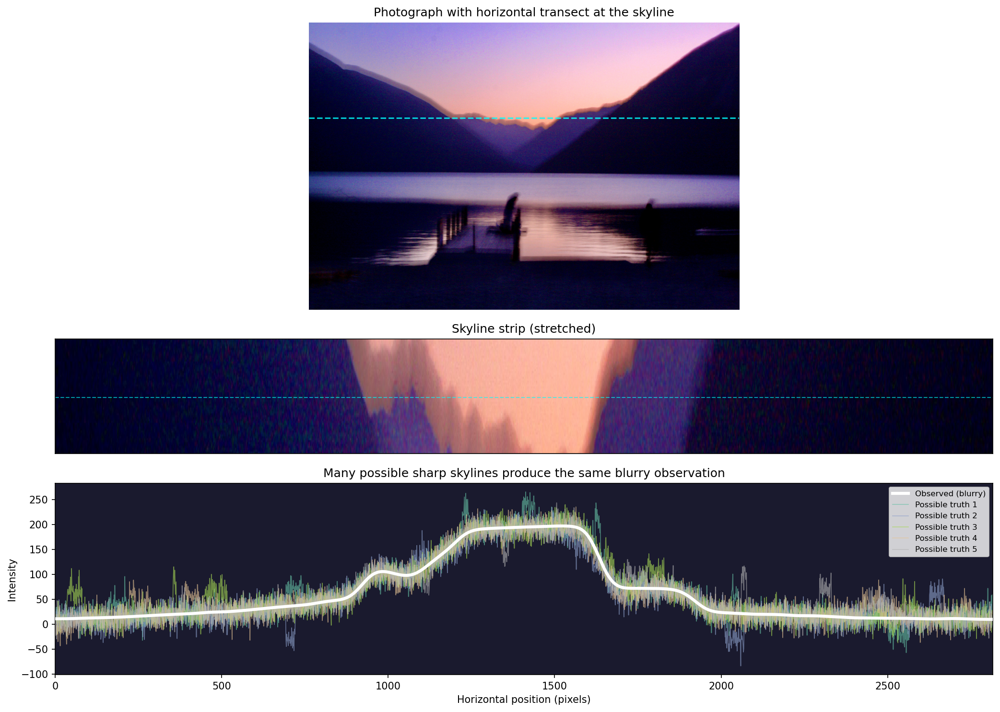

In [7]:
# Extract a horizontal slice at the approximate skyline
sky_row = photo.shape[0] // 3  # roughly where mountains meet sky
slice_observed = photo_gray[sky_row, :]

# Smooth it further to get the "observed" blurry profile
sigma_blur = 30
slice_blurred = gaussian_filter(slice_observed, sigma=sigma_blur)

# Generate multiple plausible "sharp" skylines that blur to the same profile
np.random.seed(42)
n_candidates = 5

fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [3, 1.2, 2]})

# Top panel: full photograph with the slice line marked
axes[0].imshow(photo)
axes[0].axhline(y=sky_row, color='cyan', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].set_title('Photograph with horizontal transect at the skyline')
axes[0].axis('off')

# Middle panel: the thin strip around the skyline, stretched vertically
strip_half = 30  # pixels above/below the line
strip = photo[sky_row - strip_half:sky_row + strip_half, :, :]
axes[1].imshow(strip, aspect='auto')
axes[1].axhline(y=strip_half, color='cyan', linewidth=1, linestyle='--', alpha=0.6)
axes[1].set_title('Skyline strip (stretched)')
axes[1].set_yticks([])
axes[1].set_xticks([])

# Bottom panel: intensity profiles — observed + candidates
x = np.arange(len(slice_blurred))
axes[2].plot(x, slice_blurred, 'w-', linewidth=3, label='Observed (blurry)', zorder=10)

colors_cand = plt.cm.Set2(np.linspace(0, 1, n_candidates))
for i in range(n_candidates):
    noise = np.random.randn(len(slice_blurred)) * 15
    edges = np.zeros_like(slice_blurred)
    n_edges = np.random.randint(8, 20)
    for _ in range(n_edges):
        pos = np.random.randint(0, len(edges))
        width = np.random.randint(5, 40)
        height = np.random.randn() * 25
        edges[max(0, pos - width):pos + width] += height
    candidate = slice_blurred + edges + noise
    axes[2].plot(x, candidate, '-', color=colors_cand[i], alpha=0.6, linewidth=0.8,
                 label=f'Possible truth {i+1}')

axes[2].set_facecolor('#1a1a2e')
axes[2].set_xlim(0, len(slice_blurred))
axes[2].set_xlabel('Horizontal position (pixels)')
axes[2].set_ylabel('Intensity')
axes[2].set_title('Many possible sharp skylines produce the same blurry observation')
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. Non-unique reconstruction: the sub-pixel problem

Consider a MODIS pixel that reads **-20°C**. What surface produced that temperature?

Here are some possibilities — each panel shows a different 10x10 sub-pixel arrangement
of surface types (open water at ~-2°C, thin ice at ~-15°C, thick ice at ~-35°C) that
all produce the **same average temperature**.

The pixel cannot distinguish between these worlds.

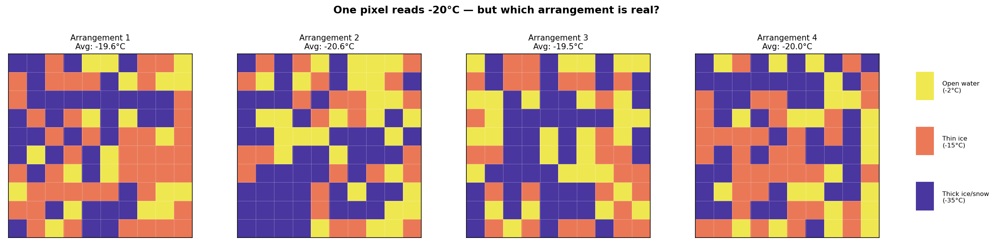

In [8]:
# Define surface types with characteristic temperatures
surface_types = {
    'Open water': -2,
    'Thin ice': -15,
    'Thick ice/snow': -35,
}
type_names = list(surface_types.keys())
type_temps = np.array(list(surface_types.values()))

target_temp = -20.0  # the observed pixel temperature
grid_size = 10
n_examples = 4

np.random.seed(123)
fig, axes = plt.subplots(1, n_examples + 1, figsize=(18, 4),
                         gridspec_kw={'width_ratios': [1]*n_examples + [0.4]})

for ex in range(n_examples):
    # Random fractions that produce the target temperature
    # Solve: f1*T1 + f2*T2 + f3*T3 = target, f1+f2+f3=1
    for _ in range(10000):
        f = np.random.dirichlet([2, 2, 2])
        avg = np.sum(f * type_temps)
        if abs(avg - target_temp) < 0.5:
            break

    # Create sub-pixel grid
    n_cells = grid_size * grid_size
    counts = np.round(f * n_cells).astype(int)
    counts[-1] = n_cells - counts[:-1].sum()

    labels = np.concatenate([np.full(c, i) for i, c in enumerate(counts)])
    np.random.shuffle(labels)
    grid = labels.reshape(grid_size, grid_size)

    # Temperature grid
    temp_grid = type_temps[grid]
    actual_avg = np.mean(temp_grid)

    im = axes[ex].imshow(temp_grid, cmap=cmocean.cm.thermal, vmin=-45, vmax=0,
                         interpolation='nearest')
    axes[ex].set_title(f'Arrangement {ex+1}\nAvg: {actual_avg:.1f}°C', fontsize=10)
    axes[ex].set_xticks([])
    axes[ex].set_yticks([])

    # Add grid lines
    for x in range(grid_size+1):
        axes[ex].axhline(x-0.5, color='white', linewidth=0.3, alpha=0.5)
        axes[ex].axvline(x-0.5, color='white', linewidth=0.3, alpha=0.5)

# Legend panel — colors must match imshow normalization (vmin=-45, vmax=0)
axes[-1].axis('off')
for i, (name, temp) in enumerate(surface_types.items()):
    legend_color = cmocean.cm.thermal((temp - (-45)) / (0 - (-45)))
    axes[-1].add_patch(plt.Rectangle((0.1, 0.75 - i*0.3), 0.2, 0.15,
                       color=legend_color,
                       transform=axes[-1].transAxes))
    axes[-1].text(0.4, 0.82 - i*0.3, f'{name}\n({temp}°C)',
                 transform=axes[-1].transAxes, fontsize=8, va='center')

plt.suptitle(f'One pixel reads {target_temp:.0f}°C — but which arrangement is real?',
            fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 7. Frequency content: what the blur suppresses

An image can be decomposed into spatial frequencies — low frequencies are the broad gradients
of color, high frequencies are the sharp edges and fine texture.

Blur acts as a **low-pass filter**: it attenuates high frequencies and keeps the smooth variations.

Below, we take the photograph at increasing levels of blur and compute its **radially averaged
power spectrum** — a summary of how much energy exists at each spatial frequency.
As blur increases, the high-frequency tail drops off: that detail is no longer carried by the image.

We overlay all four spectra on one plot so you can directly see the progressive loss.


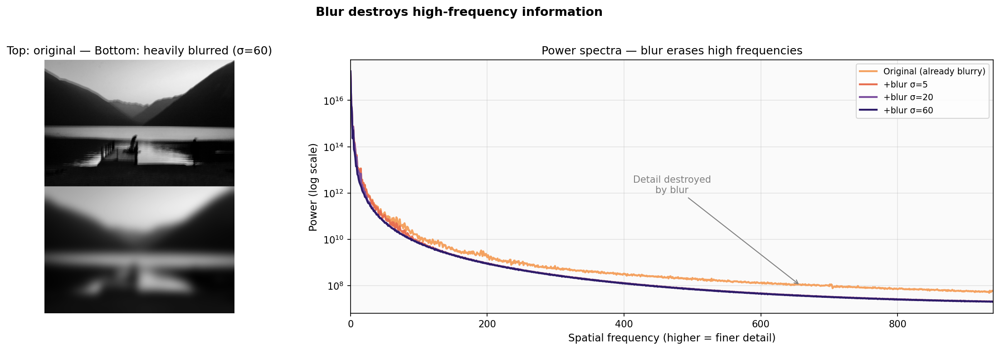

In [9]:
# FFT analysis of the photograph at different blur levels
sigmas = [0, 5, 20, 60]
colors_fft = ['#f4a261', '#e76f51', '#7b4f9e', '#2d1b69']
labels_fft = ['Original (already blurry)', '+blur σ=5', '+blur σ=20', '+blur σ=60']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 3]})

# Left: show the images stacked
for i, s in enumerate(sigmas):
    if s == 0:
        img = photo_gray
    else:
        img = gaussian_filter(photo_gray, sigma=s)

# Show just original vs most blurred
axes[0].imshow(np.vstack([photo_gray, gaussian_filter(photo_gray, sigma=60)]), cmap='gray')
axes[0].set_title('Top: original — Bottom: heavily blurred (σ=60)')
axes[0].axis('off')

# Right: overlay all power spectra
for i, s in enumerate(sigmas):
    if s == 0:
        img = photo_gray
    else:
        img = gaussian_filter(photo_gray, sigma=s)

    f_transform = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f_transform)
    magnitude = np.abs(f_shift)**2

    cy, cx = magnitude.shape[0] // 2, magnitude.shape[1] // 2
    Y, X = np.ogrid[:magnitude.shape[0], :magnitude.shape[1]]
    r = np.sqrt((X - cx)**2 + (Y - cy)**2).astype(int)
    max_r = min(cx, cy)
    radial_profile = np.zeros(max_r)
    for ri in range(max_r):
        radial_profile[ri] = np.mean(magnitude[r == ri])

    axes[1].semilogy(radial_profile, color=colors_fft[i], linewidth=2, label=labels_fft[i])

axes[1].set_xlabel('Spatial frequency (higher = finer detail)', fontsize=11)
axes[1].set_ylabel('Power (log scale)', fontsize=11)
axes[1].set_title('Power spectra — blur erases high frequencies')
axes[1].legend(fontsize=9)
axes[1].set_facecolor('#fafafa')
axes[1].set_xlim(0, max_r)
axes[1].grid(True, alpha=0.3)

# Annotate
axes[1].annotate('Detail destroyed\nby blur', xy=(max_r*0.7, 1e8),
                fontsize=10, color='gray', ha='center',
                arrowprops=dict(arrowstyle='->', color='gray'),
                xytext=(max_r*0.5, 1e12))

plt.suptitle('Blur destroys high-frequency information', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Information entropy: quantifying the loss

How do we put a *number* on how much variation a pixelated image contains?

[**Shannon entropy**](https://en.wikipedia.org/wiki/Entropy_(information_theory)) measures
the average "surprise" in the pixel values:

$$
H = -\sum_{i=1}^{K} \, p_i \, \log_2(p_i)
$$

where $K$ is the number of histogram bins (here 256), and $p_i$ is the fraction of pixels
whose value falls in bin $i$. $H$ is measured in **bits**. An image where pixel values are
spread across many bins (lots of variety) has high $H$. An image where large blocks share
the same value (smooth, pixelated, averaged) has low $H$.

As we progressively pixelate the photograph — collapsing fine detail into block averages,
just as a satellite sensor averages everything inside its footprint — $H$ drops.
A reconstruction algorithm with strong priors (learned denoisers, sparsity assumptions)
can *hallucinate* plausible fine detail, but nothing in the coarse image uniquely
determines what was there.

The dashed line shows $H$ for the MODIS thermal scene. To compute it, we rescale the
~110x100 grid of pixel temperatures to 0–255 and compute entropy the same way.

**A caveat:** this histogram-based entropy depends on both the variety of the signal *and*
the number of pixels — a larger image can populate more bins and appear to have higher entropy.
The photograph (5.3 million pixels) and the MODIS scene (~11,000 pixels) differ enormously
in sample size, so the absolute values are not directly comparable. What *is* meaningful
is the **shape of the curve**: watching entropy fall as we pixelate the same image shows
variation being averaged out, independent of image size.


Photograph: 1880x2816 = 5,294,080 pixels, H = 7.17 bits
MODIS thermal subset: 110x100 = 11,000 valid pixels, H = 6.61 bits
(Absolute values not directly comparable due to different sample sizes — see caveat above)


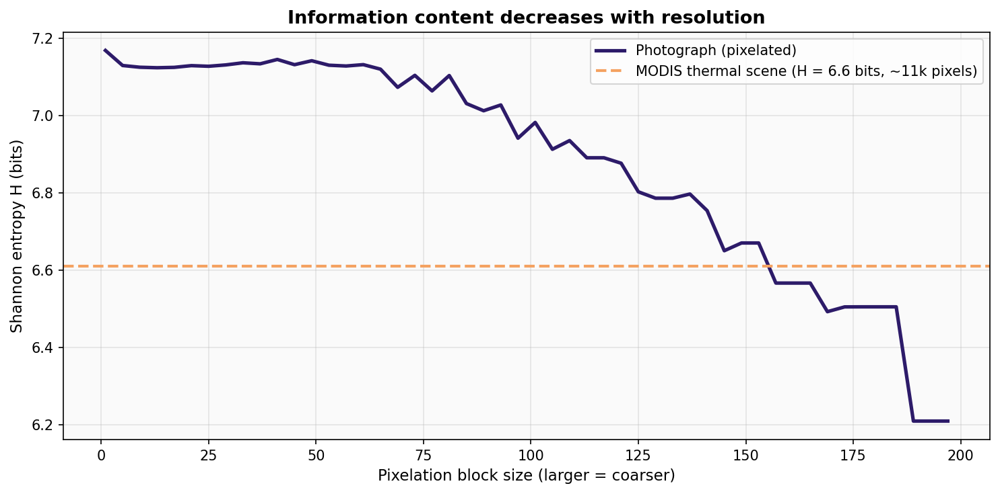

In [10]:
from PIL import Image as PILImage

def image_entropy(img_gray, bins=256):
    """Shannon entropy H = -sum(p_i * log2(p_i)) over a 256-bin histogram."""
    hist, _ = np.histogram(img_gray.ravel(), bins=bins, range=(0, 255), density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log2(hist))

# Compute entropy at different pixelation levels of the photograph
block_sizes = np.arange(1, 200, 4)
entropies = []
h, w = photo_gray.shape

for block in block_sizes:
    small = np.array(PILImage.fromarray(photo_gray.astype(np.uint8)).resize(
        (max(1, w//block), max(1, h//block)), PILImage.BILINEAR))
    big = np.array(PILImage.fromarray(small).resize((w, h), PILImage.NEAREST))
    entropies.append(image_entropy(big))

# Compute entropy for the MODIS thermal scene
# Rescale temperatures to 0-255 so we can apply the same histogram method
B31_valid = B31_sub[~np.isnan(B31_sub)]
B31_norm = ((B31_valid - B31_valid.min()) / (B31_valid.max() - B31_valid.min()) * 255).astype(np.uint8)
modis_entropy = image_entropy(B31_norm)

print(f'Photograph: {h}x{w} = {h*w:,} pixels, H = {entropies[0]:.2f} bits')
print(f'MODIS thermal subset: {B31_sub.shape[0]}x{B31_sub.shape[1]} = {np.sum(~np.isnan(B31_sub)):,} valid pixels, H = {modis_entropy:.2f} bits')
print(f'(Absolute values not directly comparable due to different sample sizes — see caveat above)')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(block_sizes, entropies, '-', color='#2d1b69', linewidth=2.5, label='Photograph (pixelated)')
ax.axhline(y=modis_entropy, color='#f4a261', linewidth=2, linestyle='--',
           label=f'MODIS thermal scene (H = {modis_entropy:.1f} bits, ~11k pixels)')
ax.set_xlabel('Pixelation block size (larger = coarser)', fontsize=11)
ax.set_ylabel('Shannon entropy H (bits)', fontsize=11)
ax.set_title('Information content decreases with resolution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_facecolor('#fafafa')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. The parallel

**Left**: many sharp skylines blur to the same photograph.
**Right**: many sub-pixel mosaics average to the same pixel temperature.

Both are examples of a **many-to-one map**. The forward process (blur, spatial averaging)
is well-defined. The inverse is not — it has many solutions.

This is **information loss** in the precise sense of a non-invertible forward map.
The sharp scene existed; the observation keeps only what survives the averaging.
Recovering anything more requires adding something the observation itself doesn't carry —
a prior, an assumption, a model, another measurement.


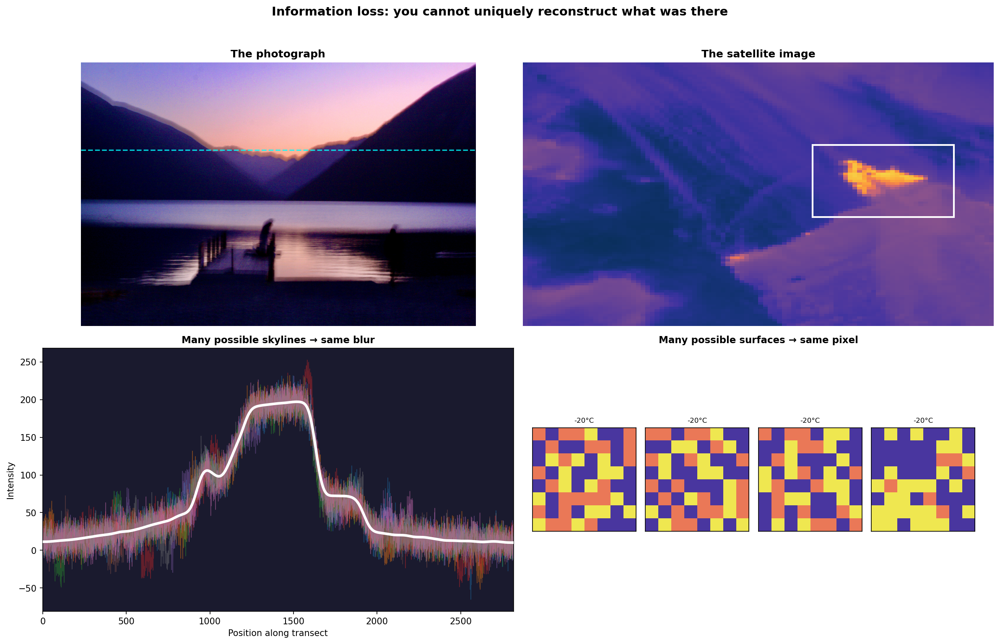

In [11]:
# Final showcase figure: the parallel
fig = plt.figure(figsize=(16, 10))

sky_row_final = photo.shape[0] // 3

# --- Top row: the two observations with annotations ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(photo)
ax1.axhline(y=sky_row_final, color='cyan', linewidth=1.5, linestyle='--', alpha=0.8)
ax1.set_title('The photograph', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(2, 2, 2)
im = ax2.imshow(B31_sub, cmap=cmocean.cm.thermal, vmin=-45, vmax=0, aspect='auto')
ax2.set_title('The satellite image', fontsize=12, fontweight='bold')
ax2.axis('off')

# Re-draw the zoom box from section 3 on the MODIS image
from scipy.ndimage import uniform_filter
warm_smooth = uniform_filter(np.nan_to_num(B31_sub, nan=-50), size=15)
warm_center = np.unravel_index(np.argmax(warm_smooth), warm_smooth.shape)
rc, cc = warm_center
half = 15
r1_z = max(0, rc - half); r2_z = min(B31_sub.shape[0], rc + half)
c1_z = max(0, cc - half); c2_z = min(B31_sub.shape[1], cc + half)
rect_modis = plt.Rectangle((c1_z, r1_z), c2_z - c1_z, r2_z - r1_z,
                            linewidth=2, edgecolor='white', facecolor='none')
ax2.add_patch(rect_modis)

# --- Bottom left: skyline profiles ---
ax3 = fig.add_subplot(2, 2, 3)
x = np.arange(photo.shape[1])
slice_blurred_final = gaussian_filter(photo_gray[sky_row_final, :], sigma=30)
ax3.plot(x, slice_blurred_final, 'w-', linewidth=3, zorder=10, label='Observed')
np.random.seed(7)
for i in range(8):
    noise = np.random.randn(len(slice_blurred_final)) * 12
    edges = np.zeros_like(slice_blurred_final)
    for _ in range(np.random.randint(8, 25)):
        pos = np.random.randint(0, len(edges))
        wid = np.random.randint(5, 50)
        ht = np.random.randn() * 20
        edges[max(0, pos - wid):pos + wid] += ht
    candidate = slice_blurred_final + edges + noise
    ax3.plot(x, candidate, '-', alpha=0.4, linewidth=0.7)
ax3.set_facecolor('#1a1a2e')
ax3.set_title('Many possible skylines \u2192 same blur', fontsize=11, fontweight='bold')
ax3.set_xlabel('Position along transect')
ax3.set_ylabel('Intensity')
ax3.set_xlim(0, len(slice_blurred_final))

# --- Bottom right: sub-pixel grids ---
ax4 = fig.add_subplot(2, 2, 4)
np.random.seed(99)
for j in range(4):
    for _ in range(10000):
        f = np.random.dirichlet([2, 2, 2])
        avg = np.sum(f * type_temps)
        if abs(avg - target_temp) < 0.5:
            break
    n_cells = 8 * 8
    counts = np.round(f * n_cells).astype(int)
    counts[-1] = n_cells - counts[:-1].sum()
    labels_arr = np.concatenate([np.full(c, i) for i, c in enumerate(counts)])
    np.random.shuffle(labels_arr)
    temp_grid = type_temps[labels_arr.reshape(8, 8)]

    inset = ax4.inset_axes([0.02 + j * 0.24, 0.15, 0.22, 0.7])
    inset.imshow(temp_grid, cmap=cmocean.cm.thermal, vmin=-45, vmax=0, interpolation='nearest')
    inset.set_title(f'{np.mean(temp_grid):.0f}°C', fontsize=8)
    inset.set_xticks([])
    inset.set_yticks([])

ax4.set_facecolor('#fafafa')
ax4.set_title('Many possible surfaces \u2192 same pixel', fontsize=11, fontweight='bold')
ax4.axis('off')

plt.suptitle('Information loss: you cannot uniquely reconstruct what was there',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10. One reconstruction

A watercolor painting of the same scene — painted from the blurry photograph.

The painter had to decide: where exactly is the ridge of each mountain?
How sharp is the dock? Where does the reflection end and the shore begin?

The photograph left all of this ambiguous. The painting resolves it — but differently
than another painter would. It is one point drawn from the set of scenes consistent with the observation.


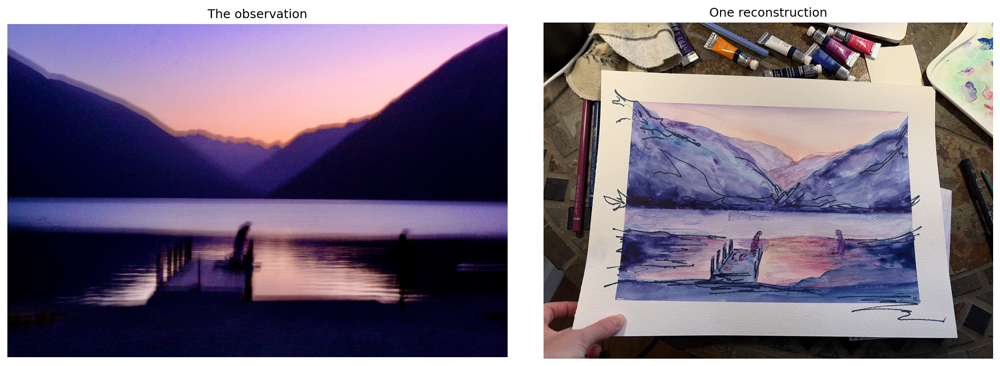

In [12]:
# Load the painting
painting = np.array(Image.open('painting.jpeg'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(photo)
axes[0].set_title('The observation', fontsize=12)
axes[0].axis('off')

axes[1].imshow(painting)
axes[1].set_title('One reconstruction', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

---

*Building 21 Showcase — Elena Savidge, McGill University*

The uncertainty in an observation is not just a number attached to a measurement.
It is the **set of possible scenes consistent with what we see**.

In a blurry photograph, it is every skyline that could be hiding behind the glow.
In a satellite pixel, it is every arrangement of ice and water that could produce that temperature.

What we observe is real, but it is not the whole story. The rest lives in the set of solutions
consistent with the observation, and nothing in the observation alone selects one of them.
Uncertainty, in this sense, is not a flaw of the instrument. It is a structural consequence
of mapping a rich scene onto a smaller set of numbers.

---

This is exploratory, playful work. If something doesn't sit right, or you spot an error, please [email me](mailto:elena.savidge@mcgill.ca). :)

<sub>Conceived and directed by Elena Savidge across many conversations and Building 21 working sessions.
Implementation assistance from ChatGPT, Google Gemini, and Claude Code.</sub>
